---
execute:
    enabled: true
---

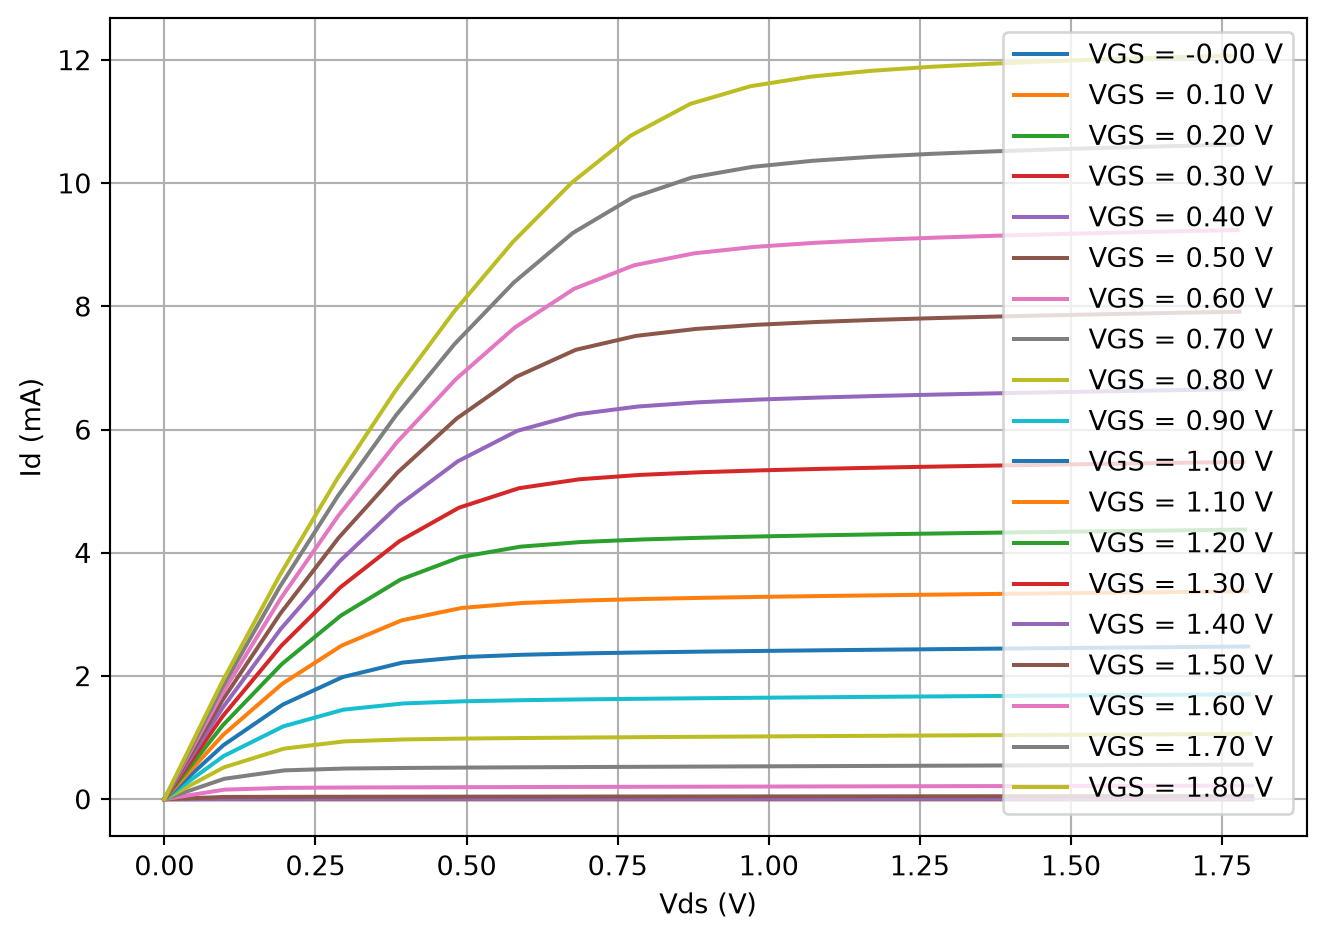

In [1]:
#| label: fig-id-vds
#| fig-cap: "Drain current $I_D$ versus drain-source voltage $V_{DS}$ for different $V_{GS}$ values."

import numpy as np
from PyLTSpice import RawRead
import matplotlib.pyplot as plt

raw = RawRead("./ngspice/NMOS.raw", dialect="ngspice")

par_names = raw.get_trace_names()

par_prefix = par_names[1].split('[')[0]

short_names = {}
for name in par_names:
    short_name = name.split('[', 1)[1].split(']', 1)[0] if '[' in name and ']' in name else name
    short_names[short_name] = name


var1 = raw.get_trace(short_names["id"]).get_wave()
var2 = raw.get_trace(short_names["vds"]).get_wave()
var3 = raw.get_trace(short_names["vgs"]).get_wave()
sweep = raw.get_trace(short_names["v(v-sweep)"]).get_wave()

v_sweep = np.array(list(dict.fromkeys(sweep)))

var1 = np.reshape(var1, (len(v_sweep), -1), order='F')
var2 = np.reshape(var2, (len(v_sweep), -1), order='F')
var3 = np.reshape(var3, (len(v_sweep), -1), order='F')
vgs = var3[0, :]


plt.figure(figsize=(7, 5))
plt.plot(var2, var1 * 1000)
plt.legend([f"VGS = {v:.2f} V" for v in vgs])

plt.xlabel("Vds (V)")
plt.ylabel("Id (mA)")
plt.grid(True)

plt.tight_layout()
plt.show()

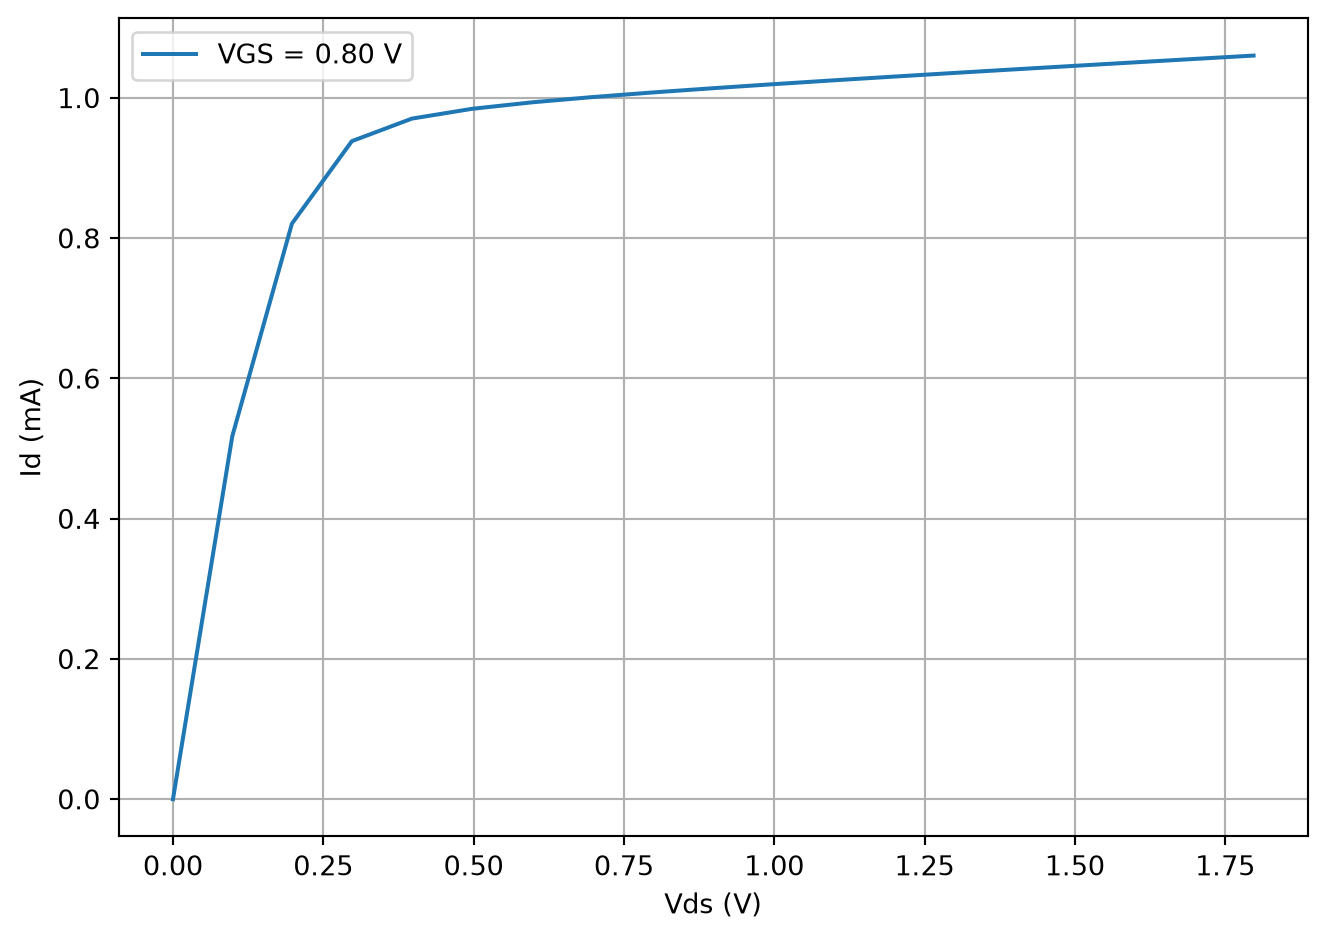

In [2]:
#| label: fig-id-vds-0.8
#| fig-cap: "Drain current $I_D$ versus drain-source voltage $V_{DS}$ for $V_{GS}=0.8$."

#target curve
target_vgs = 0.8
idx = np.argmin(np.abs(vgs - target_vgs))

plt.figure(figsize=(7, 5))
plt.plot(var2[:, idx], var1[:, idx] * 1000)
plt.legend([f"VGS = {vgs[idx]:.2f} V"])

plt.xlabel("Vds (V)")
plt.ylabel("Id (mA)")
plt.grid(True)

plt.tight_layout()
plt.show()

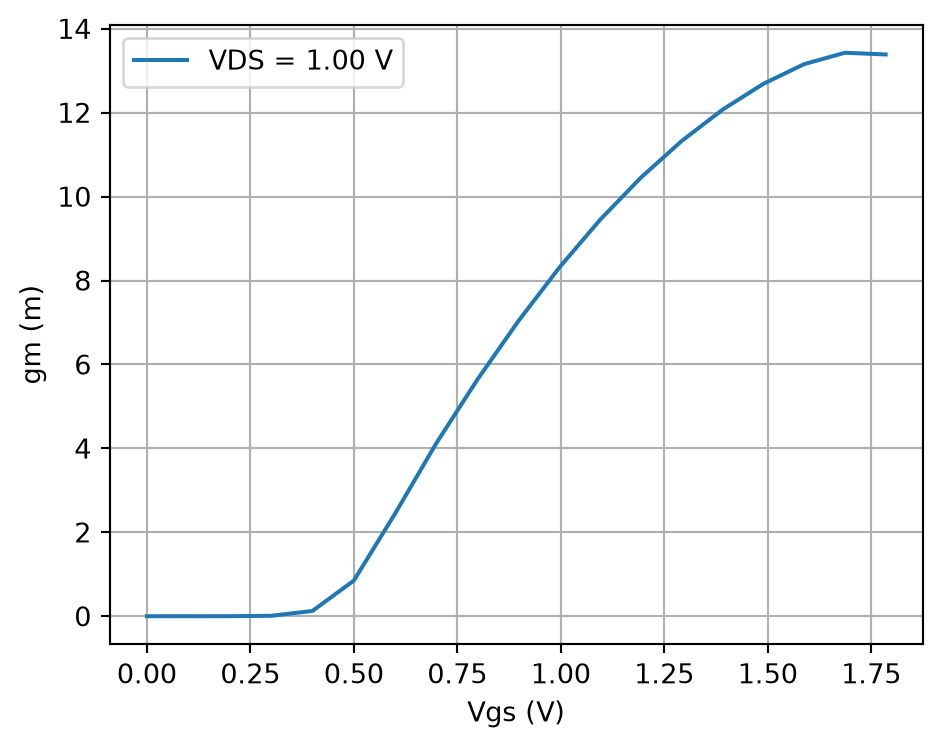

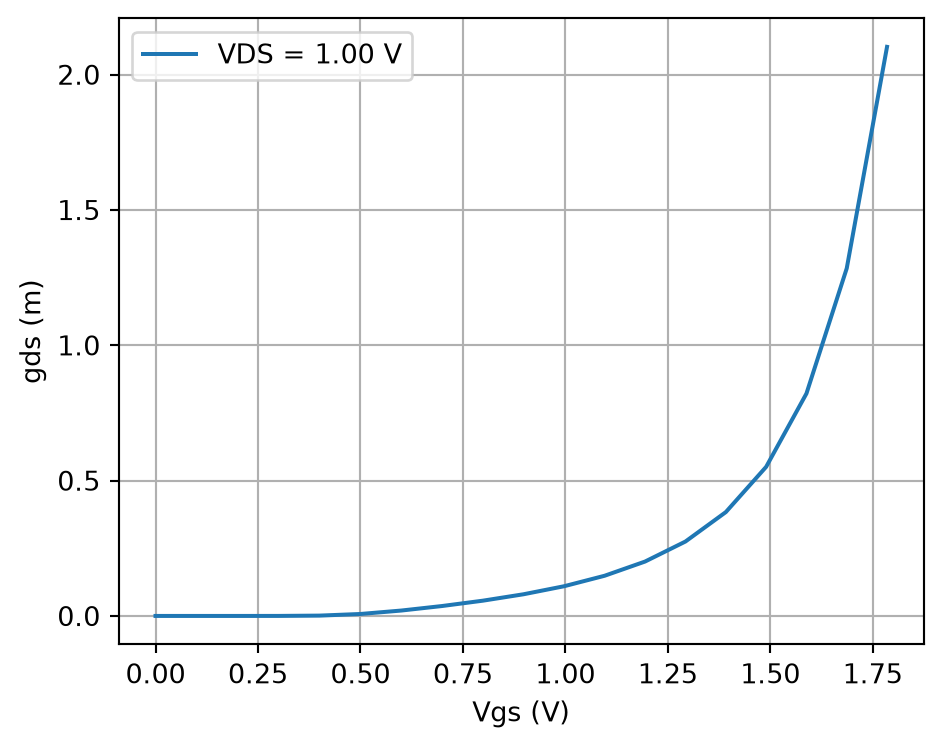

In [3]:
#| label: fig-gmgds-vgs
#| fig-cap: Variation of $g_m$ and $g_{ds} versus $V_{GS}$ for $V_{DS}=1V$.
#| fig-subcap:
#|   - $g_m$ versus $V_{GS}$
#|   - $g_{ds}$ versus $V_{GS}$
#| layout-ncol: 2

var1 = raw.get_trace(short_names["gm"]).get_wave()
var2 = raw.get_trace(short_names["vgs"]).get_wave()
var3 = raw.get_trace(short_names["vds"]).get_wave()
sweep = raw.get_trace(short_names["v(v-sweep)"]).get_wave()

v_sweep = np.array(list(dict.fromkeys(sweep)))

var1 = np.reshape(var1, (len(v_sweep), -1), order='F')
var2 = np.reshape(var2, (len(v_sweep), -1), order='F')
var3 = np.reshape(var3, (len(v_sweep), -1), order='F')
vds = var3.T[0, :]

#target curve
target_vds = 1
idx = np.argmin(np.abs(vds - target_vds))

plt.figure(figsize=(5, 4))
plt.plot(var2.T[:, idx], var1.T[:, idx] * 1000)
plt.legend([f"VDS = {vds[idx]:.2f} V"])

plt.xlabel("Vgs (V)")
plt.ylabel("gm (m)")
plt.grid(True)

plt.tight_layout()
plt.show()

var1 = raw.get_trace(short_names["gds"]).get_wave()
var1 = np.reshape(var1, (len(v_sweep), -1), order='F')

plt.figure(figsize=(5, 4))
plt.plot(var2.T[:, idx], var1.T[:, idx] * 1000)
plt.legend([f"VDS = {vds[idx]:.2f} V"])

plt.xlabel("Vgs (V)")
plt.ylabel("gds (m)")
plt.grid(True)

plt.tight_layout()
plt.show()


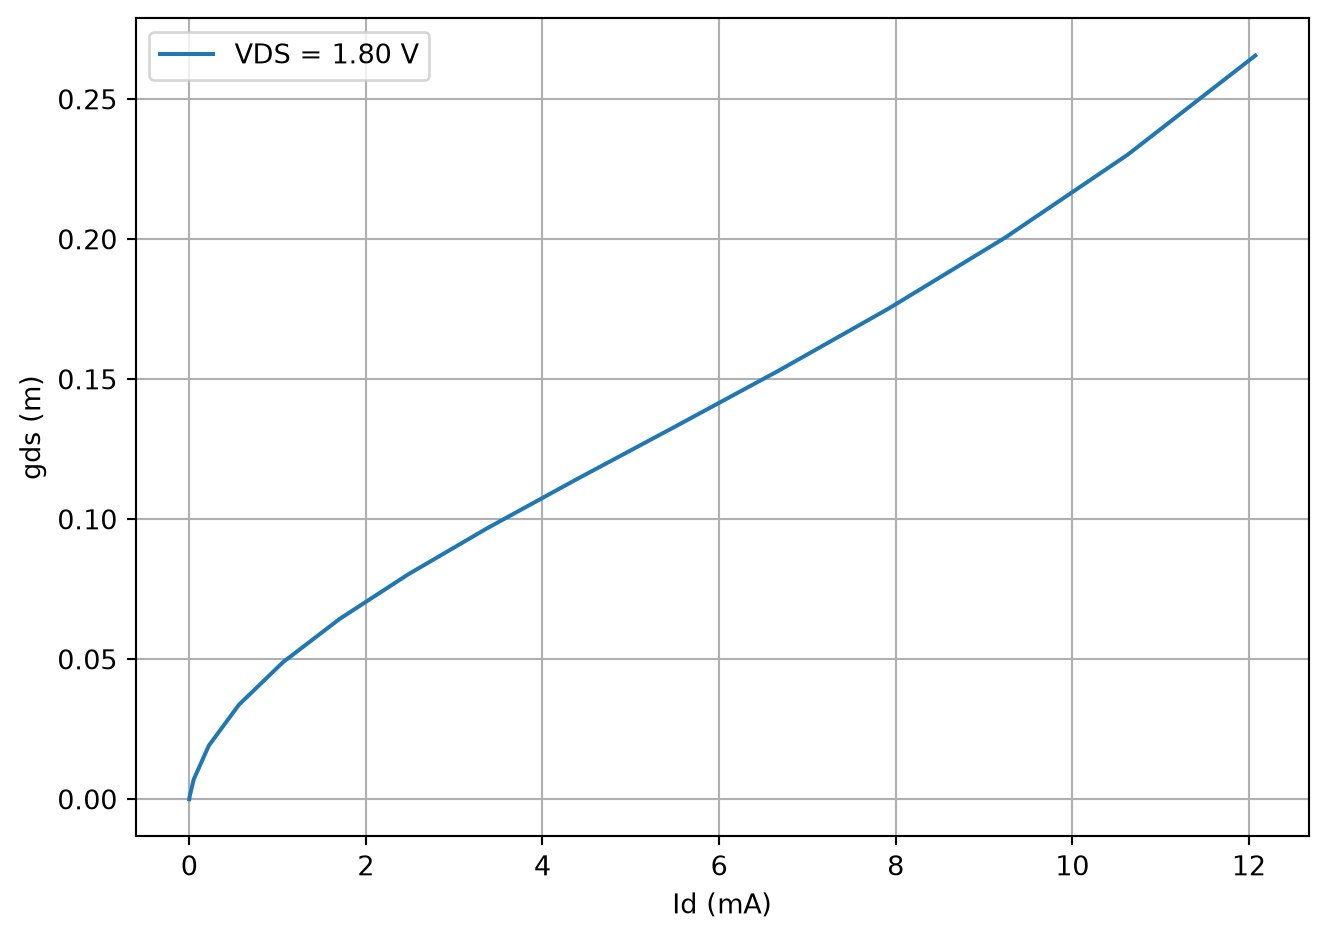

In [4]:
#| label: fig-gds-id
#| fig-cap: "Variation of $g_{ds}$ versus Drain current $I_d$ for $V_{DS}=1.8V$."

var1 = raw.get_trace(short_names["gds"]).get_wave()
var1 = np.reshape(var1, (len(v_sweep), -1), order='F')
var2 = raw.get_trace(short_names["id"]).get_wave()
var2 = np.reshape(var2, (len(v_sweep), -1), order='F')

#target curve
target_vds = 1.8
idx = np.argmin(np.abs(vds - target_vds))

plt.figure(figsize=(7, 5))
plt.plot(var2.T[:, idx] * 1000, var1.T[:, idx] * 1000)
plt.legend([f"VDS = {vds[idx]:.2f} V"])

plt.xlabel("Id (mA)")
plt.ylabel("gds (m)")
plt.grid(True)

plt.tight_layout()
plt.show()

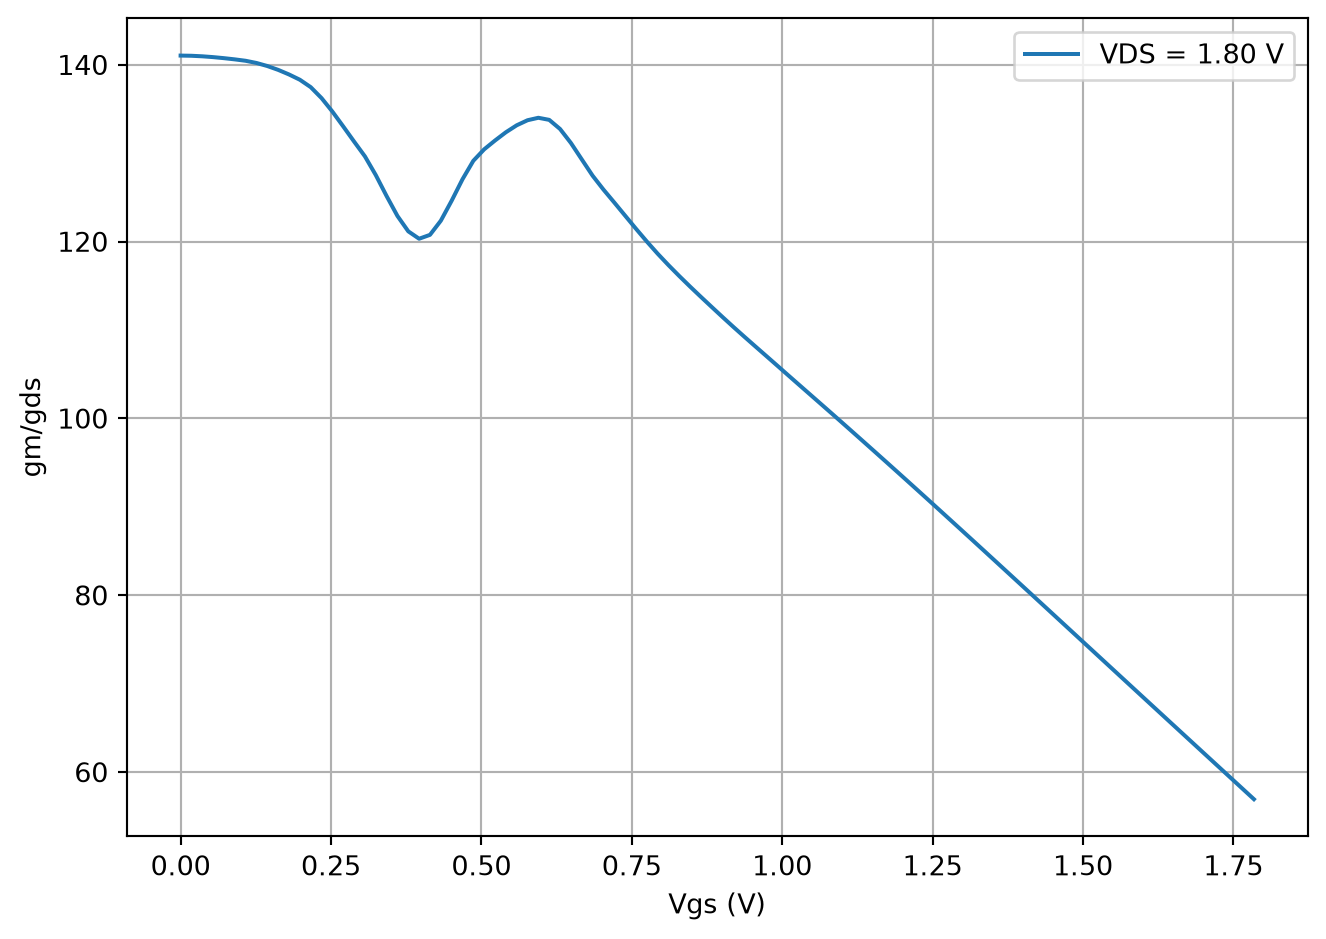

In [5]:
#| label: fig-gm_gds-vgs
#| fig-cap: "Intrinsic small-signal low-frequency gain of NMOS with W/L = 100u/1.5u."
from scipy.interpolate import PchipInterpolator

var1 = raw.get_trace(short_names["gm"]).get_wave()
var2 = raw.get_trace(short_names["vgs"]).get_wave()
var3 = raw.get_trace(short_names["vds"]).get_wave()
var4 = raw.get_trace(short_names["gds"]).get_wave()
sweep = raw.get_trace(short_names["v(v-sweep)"]).get_wave()

v_sweep = np.array(list(dict.fromkeys(sweep)))

var1 = np.reshape(var1, (len(v_sweep), -1), order='F')
var2 = np.reshape(var2, (len(v_sweep), -1), order='F')
var3 = np.reshape(var3, (len(v_sweep), -1), order='F')
var4 = np.reshape(var4, (len(v_sweep), -1), order='F')

vds = var3.T[0, :]

#target curve
target_vds = 1.8
idx = np.argmin(np.abs(vds - target_vds))

x = var2.T[:, idx]
y = var1.T[:, idx]/var4.T[:, idx]

x_smooth = np.linspace(x.min(), x.max(), 100)
interp = PchipInterpolator(x, y)
y_smooth = interp(x_smooth)

plt.figure(figsize=(7, 5))
plt.plot(x_smooth, y_smooth)
plt.legend([f"VDS = {vds[idx]:.2f} V"])

plt.xlabel("Vgs (V)")
plt.ylabel("gm/gds")
plt.grid(True)

plt.tight_layout()
plt.show()